In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('C:/Users/Sathsarani Kangara/Desktop/employee-attrition-predictor/data/processed_data.csv')

# X and y split
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8877551020408163
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       255
           1       0.67      0.31      0.42        39

    accuracy                           0.89       294
   macro avg       0.78      0.64      0.68       294
weighted avg       0.87      0.89      0.87       294



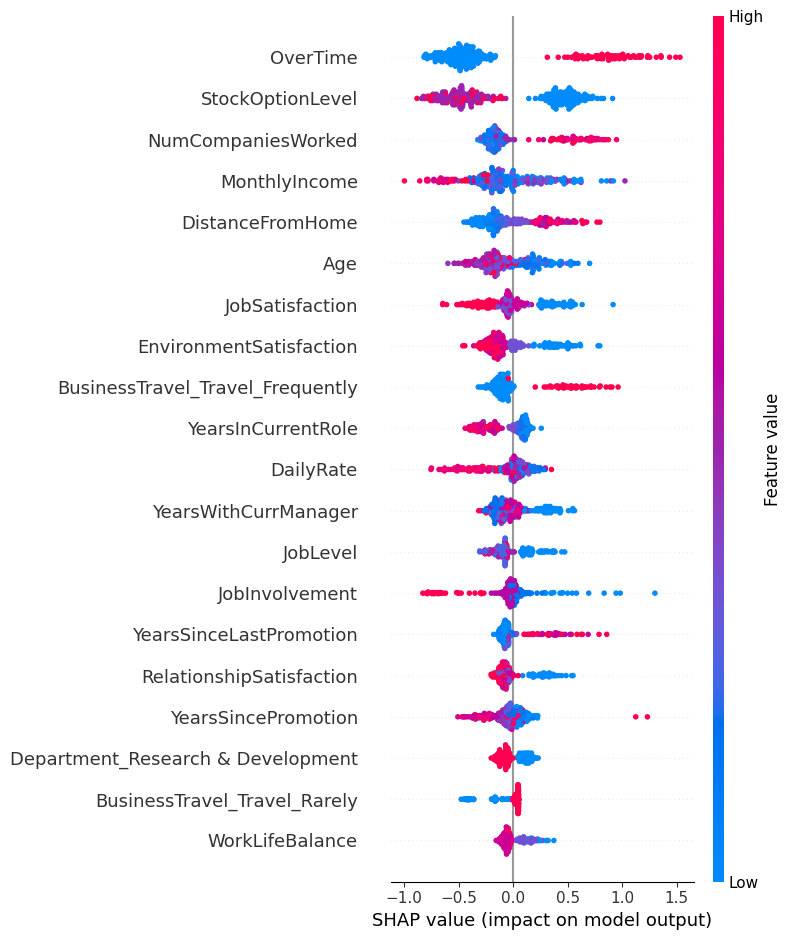

In [2]:
import shap

# SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('C:/Users/Sathsarani Kangara/Desktop/employee-attrition-predictor/outputs/08_shap_summary.png')
plt.show()


<Figure size 1000x800 with 0 Axes>

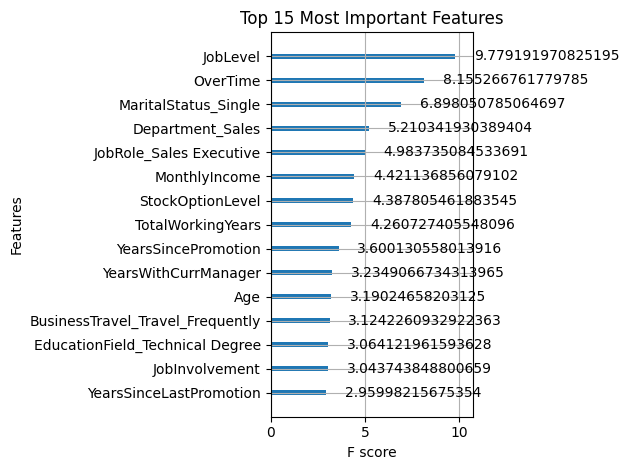

In [3]:
# Feature Importance Chart - SHAP වලට alternative
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=15, importance_type='gain')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.savefig('C:/Users/Sathsarani Kangara/Desktop/employee-attrition-predictor/outputs/08_feature_importance.png')
plt.show()